# Teoria de la Informacion para Machine Learning

**Pregunta:** En clasificacion usamos cross-entropy como loss function. Pero que ES la entropia? Por que funciona? Y que tiene que ver con la informacion?

---

## 1. La Idea Central: Informacion = Sorpresa

Claude Shannon (1948) definio la **informacion** de un evento como una medida de lo **sorprendente** que es:

$$I(x) = -\log_2 P(x)$$

- Evento muy probable (P=0.99): poca sorpresa, poca informacion → $-\log_2(0.99) = 0.014$ bits
- Evento raro (P=0.01): mucha sorpresa, mucha informacion → $-\log_2(0.01) = 6.64$ bits

**Analogia:** Si te digo "manana sale el sol" (P≈1), no te aporto informacion. Si te digo "manana hay terremoto" (P≈0.001), eso SI es informacion.

El logaritmo hace que la informacion sea **aditiva**: dos eventos independientes tienen informacion total = suma de informaciones individuales.

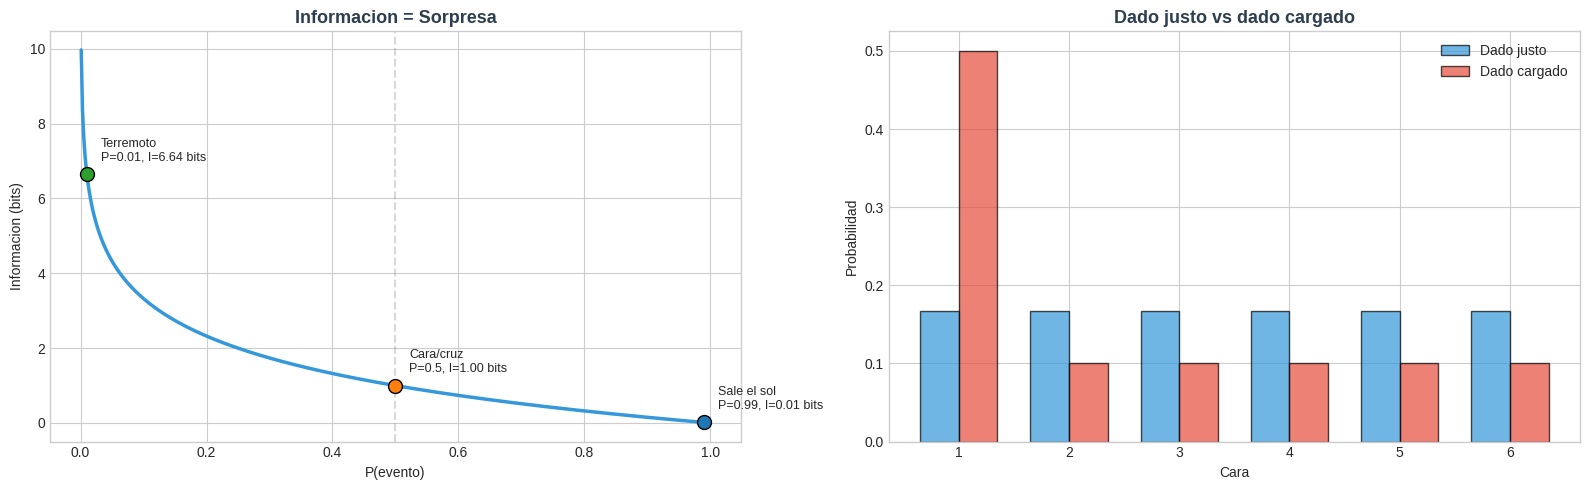

Informacion de sacar un 6 con dado justo: 2.58 bits
Informacion de sacar un 1 con dado cargado: 1.00 bits
Informacion de sacar un 6 con dado cargado: 3.32 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'

# === Informacion vs Probabilidad ===
p = np.linspace(0.001, 0.999, 500)
info = -np.log2(p)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(p, info, color=C_PRIMARY, linewidth=2.5)
ax.set_title('Informacion = Sorpresa', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('P(evento)')
ax.set_ylabel('Informacion (bits)')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3)

# Anotar ejemplos
examples = [(0.99, 'Sale el sol'), (0.5, 'Cara/cruz'), (0.01, 'Terremoto')]
for prob, label in examples:
    info_val = -np.log2(prob)
    ax.scatter([prob], [info_val], s=100, zorder=5, edgecolors='black')
    ax.annotate(f'{label}\nP={prob}, I={info_val:.2f} bits', (prob, info_val),
                textcoords="offset points", xytext=(10, 10), fontsize=9)

# Ejemplo: dado justo vs cargado
ax = axes[1]
dado_justo = np.ones(6) / 6
dado_cargado = np.array([0.5, 0.1, 0.1, 0.1, 0.1, 0.1])

x = np.arange(1, 7)
width = 0.35
ax.bar(x - width/2, dado_justo, width, color=C_PRIMARY, alpha=0.7, label='Dado justo', edgecolor='black')
ax.bar(x + width/2, dado_cargado, width, color=C_DANGER, alpha=0.7, label='Dado cargado', edgecolor='black')
ax.set_title('Dado justo vs dado cargado', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Cara')
ax.set_ylabel('Probabilidad')
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Informacion de sacar un 6 con dado justo: {-np.log2(1/6):.2f} bits")
print(f"Informacion de sacar un 1 con dado cargado: {-np.log2(0.5):.2f} bits")
print(f"Informacion de sacar un 6 con dado cargado: {-np.log2(0.1):.2f} bits")

## 2. Entropia: La Sorpresa Promedio

La **entropia** de una distribucion es la informacion promedio (sorpresa esperada):

$$H(P) = -\sum_{i} P(x_i) \log_2 P(x_i)$$

- **Maxima entropia:** cuando todos los eventos son igualmente probables (dado justo). Maxima incertidumbre.
- **Minima entropia (= 0):** cuando un evento tiene P=1. Certeza total, ninguna sorpresa.

### Interpretacion en ML

La entropia mide que tan **desordenada o incierta** es una distribucion:
- Dataset con 50% gatos, 50% perros → entropia ALTA (dificil de predecir)
- Dataset con 99% gatos, 1% perros → entropia BAJA (casi siempre es gato)

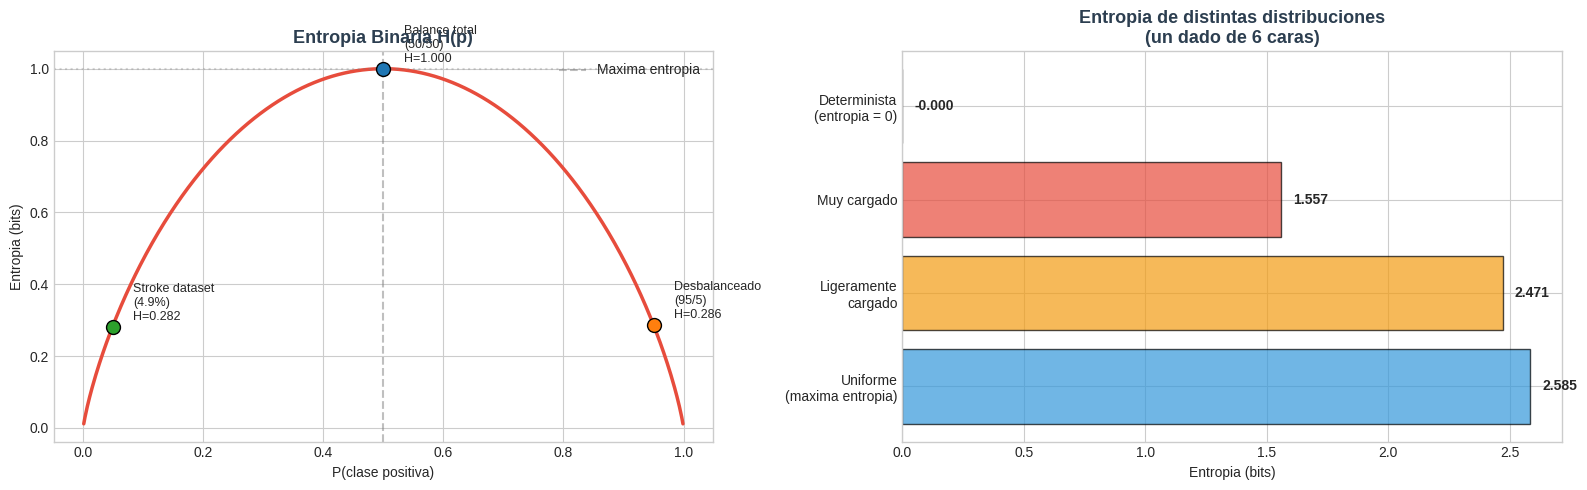

Entropia maxima de 6 opciones = log2(6) = 2.585 bits
Cuanto mas incierta la distribucion, mayor la entropia.


In [2]:
# === Entropia para distribucion binaria ===
def entropy_binary(p):
    """Entropia de una distribucion binaria [p, 1-p]."""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

p_range = np.linspace(0.001, 0.999, 500)
H = [entropy_binary(p) for p in p_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Entropia binaria
ax = axes[0]
ax.plot(p_range, H, color=C_DANGER, linewidth=2.5)
ax.set_title('Entropia Binaria H(p)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('P(clase positiva)')
ax.set_ylabel('Entropia (bits)')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Maxima entropia')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3)

# Anotar casos
cases = [
    (0.5, 'Balance total\n(50/50)'),
    (0.95, 'Desbalanceado\n(95/5)'),
    (0.049, 'Stroke dataset\n(4.9%)'),
]
for prob, label in cases:
    h = entropy_binary(prob)
    ax.scatter([prob], [h], s=100, zorder=5, edgecolors='black')
    ax.annotate(f'{label}\nH={h:.3f}', (prob, h), textcoords="offset points",
                xytext=(15, 5), fontsize=9)
ax.legend()

# Entropia de distribuciones discretas
ax = axes[1]
distributions = {
    'Uniforme\n(maxima entropia)': np.ones(6)/6,
    'Ligeramente\ncargado': np.array([0.3, 0.2, 0.15, 0.15, 0.1, 0.1]),
    'Muy cargado': np.array([0.7, 0.1, 0.05, 0.05, 0.05, 0.05]),
    'Determinista\n(entropia = 0)': np.array([1.0, 0, 0, 0, 0, 0]),
}

names = []
entropies = []
colors = [C_PRIMARY, C_ORANGE, C_DANGER, C_DARK]
for (name, dist), color in zip(distributions.items(), colors):
    h = -np.sum([p * np.log2(p) if p > 0 else 0 for p in dist])
    names.append(name)
    entropies.append(h)

ax.barh(range(len(names)), entropies, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Entropia (bits)')
ax.set_title('Entropia de distintas distribuciones\n(un dado de 6 caras)', fontsize=13, fontweight='bold', color=C_DARK)

for i, h in enumerate(entropies):
    ax.text(h + 0.05, i, f'{h:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Entropia maxima de 6 opciones = log2(6) =", np.log2(6).round(3), "bits")
print("Cuanto mas incierta la distribucion, mayor la entropia.")

## 3. Cross-Entropy: Medir que tan MAL es tu modelo

Ahora viene la conexion con ML. Si:
- $P$ es la distribucion **real** (lo que de verdad pasa)
- $Q$ es la distribucion **predicha** por tu modelo

La **cross-entropy** mide cuantos bits necesitas para codificar eventos de $P$ usando la distribucion $Q$:

$$H(P, Q) = -\sum_{i} P(x_i) \log Q(x_i)$$

### Por que es una loss function perfecta

- Si $Q = P$ (prediccion perfecta): $H(P, Q) = H(P)$ (entropia minima posible)
- Si $Q$ se aleja de $P$: $H(P, Q)$ crece — el modelo se equivoca mas
- **Gradient descent minimiza cross-entropy = hace que Q se acerque a P**

### Para clasificacion binaria

$$\text{BCE} = -\frac{1}{n}\sum_{i=1}^{n} [y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i)]$$

Donde:
- $y_i \in \{0, 1\}$: etiqueta real
- $\hat{p}_i$: probabilidad predicha por el modelo

**Es exactamente la loss function que usamos en el proyecto de stroke prediction.**

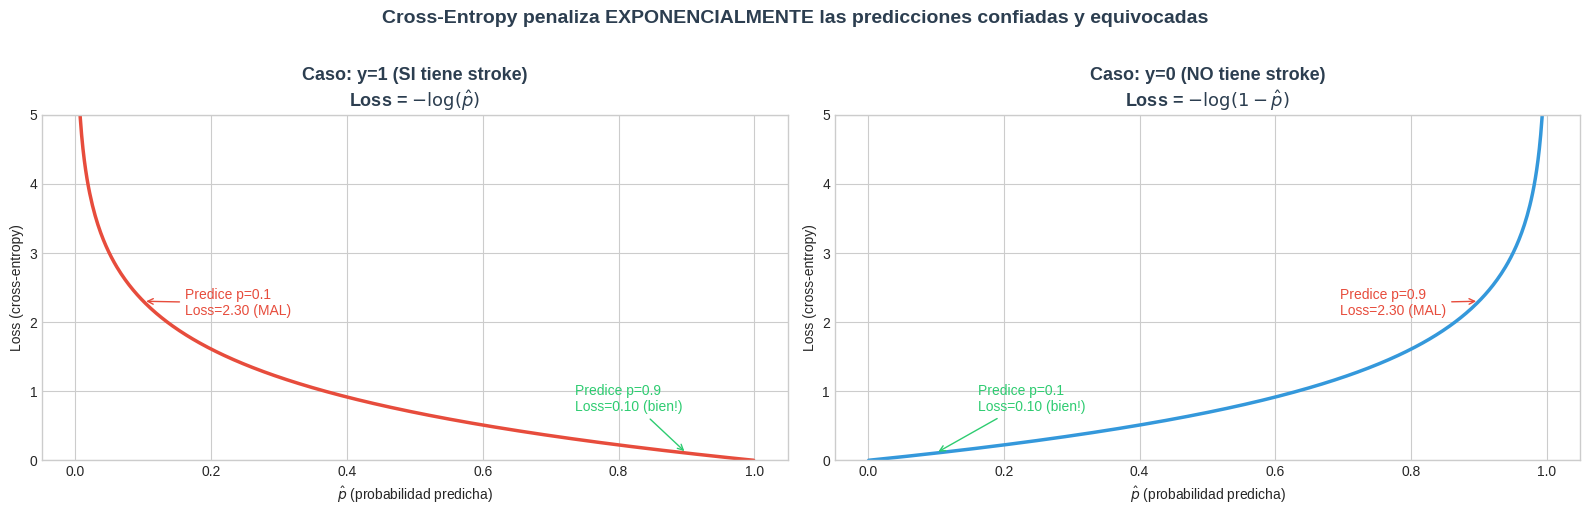

Si el paciente TIENE stroke (y=1) y predices p=0.01: loss = 4.6 (catastrofico)
Si el paciente TIENE stroke (y=1) y predices p=0.99: loss = 0.01 (perfecto)

La penalizacion es LOGARITMICA: equivocarse con confianza cuesta mucho mas.


In [3]:
# === Cross-entropy: que pasa cuando el modelo se equivoca ===
p_pred = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cuando y=1 (el paciente SI tiene stroke)
ax = axes[0]
loss_y1 = -np.log(p_pred)
ax.plot(p_pred, loss_y1, color=C_DANGER, linewidth=2.5)
ax.set_title('Caso: y=1 (SI tiene stroke)\nLoss = $-\\log(\\hat{p})$', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel(r'$\hat{p}$ (probabilidad predicha)')
ax.set_ylabel('Loss (cross-entropy)')
ax.set_ylim(0, 5)

# Anotar
ax.annotate('Predice p=0.9\nLoss=0.10 (bien!)', (0.9, -np.log(0.9)), fontsize=10,
            textcoords="offset points", xytext=(-80, 30), color=C_SUCCESS,
            arrowprops=dict(arrowstyle='->', color=C_SUCCESS))
ax.annotate('Predice p=0.1\nLoss=2.30 (MAL)', (0.1, -np.log(0.1)), fontsize=10,
            textcoords="offset points", xytext=(30, -10), color=C_DANGER,
            arrowprops=dict(arrowstyle='->', color=C_DANGER))

# Cuando y=0 (NO tiene stroke)
ax = axes[1]
loss_y0 = -np.log(1 - p_pred)
ax.plot(p_pred, loss_y0, color=C_PRIMARY, linewidth=2.5)
ax.set_title('Caso: y=0 (NO tiene stroke)\nLoss = $-\\log(1-\\hat{p})$', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel(r'$\hat{p}$ (probabilidad predicha)')
ax.set_ylabel('Loss (cross-entropy)')
ax.set_ylim(0, 5)

ax.annotate('Predice p=0.1\nLoss=0.10 (bien!)', (0.1, -np.log(0.9)), fontsize=10,
            textcoords="offset points", xytext=(30, 30), color=C_SUCCESS,
            arrowprops=dict(arrowstyle='->', color=C_SUCCESS))
ax.annotate('Predice p=0.9\nLoss=2.30 (MAL)', (0.9, -np.log(0.1)), fontsize=10,
            textcoords="offset points", xytext=(-100, -10), color=C_DANGER,
            arrowprops=dict(arrowstyle='->', color=C_DANGER))

plt.suptitle('Cross-Entropy penaliza EXPONENCIALMENTE las predicciones confiadas y equivocadas',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Si el paciente TIENE stroke (y=1) y predices p=0.01: loss = 4.6 (catastrofico)")
print("Si el paciente TIENE stroke (y=1) y predices p=0.99: loss = 0.01 (perfecto)")
print("\nLa penalizacion es LOGARITMICA: equivocarse con confianza cuesta mucho mas.")

## 4. KL-Divergence: La Distancia entre Distribuciones

La **divergencia de Kullback-Leibler** mide cuanto difiere una distribucion $Q$ de otra $P$:

$$D_{KL}(P \| Q) = \sum_{i} P(x_i) \log \frac{P(x_i)}{Q(x_i)} = H(P, Q) - H(P)$$

Es decir: **cross-entropy = entropia + KL-divergence**

$$H(P, Q) = H(P) + D_{KL}(P \| Q)$$

- $H(P)$ es constante (no depende del modelo)
- Minimizar cross-entropy = minimizar KL-divergence = acercar $Q$ a $P$

### Propiedades importantes
- $D_{KL} \geq 0$ siempre
- $D_{KL} = 0$ solo cuando $Q = P$ exactamente
- **NO es simetrica:** $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$

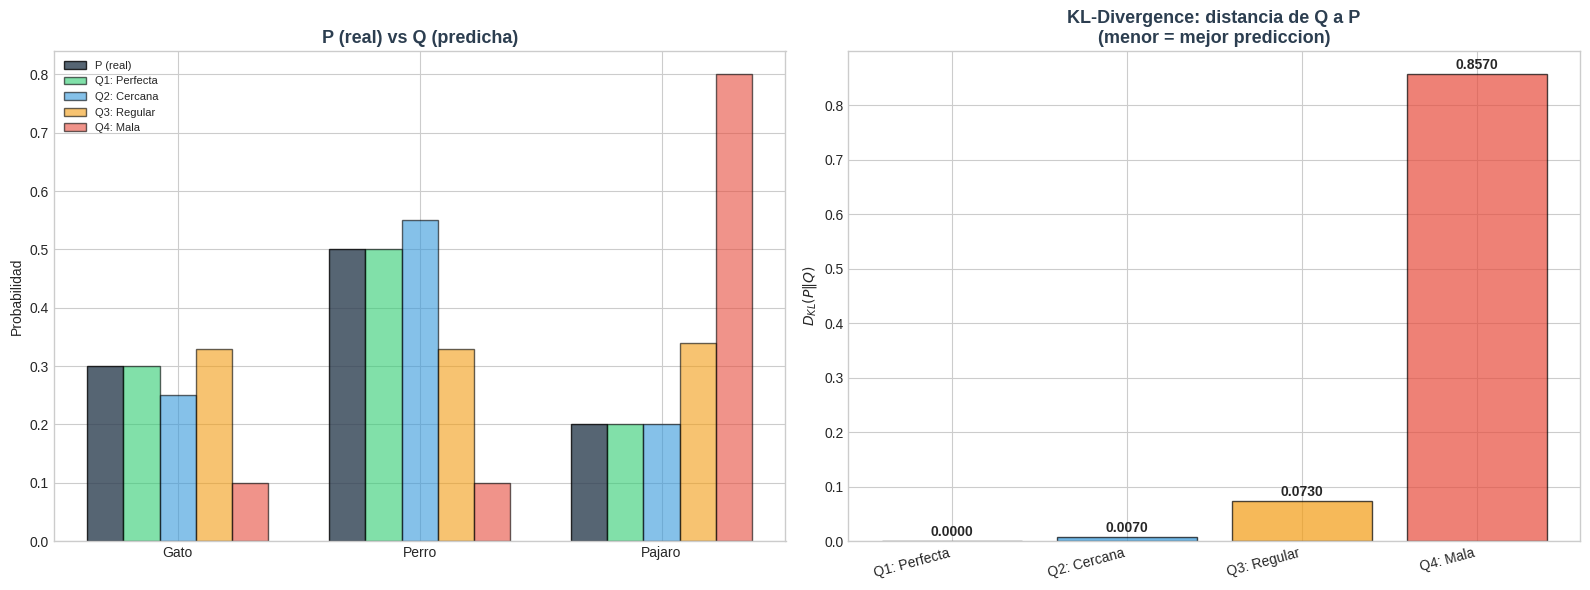

Entropia de P: H(P) = 1.0297

Modelo                 Cross-Entropy       H(P)     KL-Div
Q1: Perfecta                  1.0297     1.0297     0.0000
Q2: Cercana                   1.0367     1.0297     0.0070
Q3: Regular                   1.1027     1.0297     0.0730
Q4: Mala                      1.8867     1.0297     0.8570

Cross-Entropy = H(P) + KL. Minimizar CE = minimizar KL = acercar Q a P.


In [4]:
# === KL-Divergence visualizada ===
def kl_divergence(p, q):
    """KL(P || Q)"""
    mask = (p > 0) & (q > 0)
    return np.sum(p[mask] * np.log(p[mask] / q[mask]))

def cross_entropy_fn(p, q):
    mask = (p > 0) & (q > 0)
    return -np.sum(p[mask] * np.log(q[mask]))

# Distribucion real
P = np.array([0.3, 0.5, 0.2])
labels_dist = ['Gato', 'Perro', 'Pajaro']

# Varias distribuciones predichas (de buena a mala)
Qs = {
    'Q1: Perfecta\n[0.3, 0.5, 0.2]': np.array([0.3, 0.5, 0.2]),
    'Q2: Cercana\n[0.25, 0.55, 0.2]': np.array([0.25, 0.55, 0.2]),
    'Q3: Regular\n[0.33, 0.33, 0.34]': np.array([0.33, 0.33, 0.34]),
    'Q4: Mala\n[0.1, 0.1, 0.8]': np.array([0.1, 0.1, 0.8]),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras comparativas
ax = axes[0]
x = np.arange(len(labels_dist))
width = 0.15
ax.bar(x - 2*width, P, width, color=C_DARK, alpha=0.8, label='P (real)', edgecolor='black')
for i, (name, q) in enumerate(Qs.items()):
    colors = [C_SUCCESS, C_PRIMARY, C_ORANGE, C_DANGER]
    ax.bar(x + (i-1)*width, q, width, color=colors[i], alpha=0.6, label=name.split('\n')[0], edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels_dist)
ax.set_title('P (real) vs Q (predicha)', fontsize=13, fontweight='bold', color=C_DARK)
ax.legend(fontsize=8)
ax.set_ylabel('Probabilidad')

# KL-divergence de cada Q
ax = axes[1]
kl_values = []
ce_values = []
q_names = []
for name, q in Qs.items():
    kl_values.append(kl_divergence(P, q))
    ce_values.append(cross_entropy_fn(P, q))
    q_names.append(name.split('\n')[0])

colors = [C_SUCCESS, C_PRIMARY, C_ORANGE, C_DANGER]
bars = ax.bar(range(len(kl_values)), kl_values, color=colors, edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(q_names)))
ax.set_xticklabels(q_names, rotation=15, ha='right')
ax.set_title('KL-Divergence: distancia de Q a P\n(menor = mejor prediccion)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_ylabel('$D_{KL}(P \| Q)$')

for bar, val in zip(bars, kl_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

H_P = -np.sum(P * np.log(P))
print(f"Entropia de P: H(P) = {H_P:.4f}")
print(f"\n{'Modelo':<20} {'Cross-Entropy':>15} {'H(P)':>10} {'KL-Div':>10}")
print("=" * 58)
for name, q in Qs.items():
    ce = cross_entropy_fn(P, q)
    kl = kl_divergence(P, q)
    print(f"{name.split(chr(10))[0]:<20} {ce:>15.4f} {H_P:>10.4f} {kl:>10.4f}")
print("\nCross-Entropy = H(P) + KL. Minimizar CE = minimizar KL = acercar Q a P.")

## 5. Conexion con ML: Loss Functions y sus Derivadas

### Tabla de Loss Functions

| Problema | Loss | Formula | Derivada $\frac{\partial L}{\partial \hat{y}}$ |
|---|---|---|---|
| **Regresion** | MSE | $\frac{1}{n}\sum(y-\hat{y})^2$ | $\frac{-2}{n}(y - \hat{y})$ |
| **Regresion** | MAE | $\frac{1}{n}\sum|y-\hat{y}|$ | $\frac{-1}{n}\text{sign}(y - \hat{y})$ |
| **Clf. binaria** | BCE | $-[y\log\hat{y}+(1-y)\log(1-\hat{y})]$ | $\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$ |
| **Clf. multiclase** | CCE | $-\sum_k y_k\log\hat{y}_k$ | $-\frac{y_k}{\hat{y}_k}$ |
| **SVM** | Hinge | $\max(0, 1-y\hat{y})$ | $-y$ si $y\hat{y}<1$, $0$ si no |

### Derivada de Cross-Entropy (paso a paso)

$$L = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$$

Derivamos respecto a $\hat{y}$:

$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}$$

### La cancelacion magica con sigmoid

Si $\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$, entonces $\sigma'(z) = \hat{y}(1-\hat{y})$.

Aplicando chain rule para obtener la derivada respecto a $z$ (lo que gradient descent realmente necesita):

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y}) = \hat{y} - y$$

Los denominadores se cancelan. El gradiente es simplemente **prediccion menos realidad**.

Esto no es casualidad. Cross-entropy se disenio especificamente para sigmoid — la simplificacion hace que gradient descent sea eficiente y estable.

### Para MSE (comparacion)

Si usamos MSE con sigmoid: $\frac{\partial L}{\partial z} = -\frac{2}{n}(y-\hat{y}) \cdot \hat{y}(1-\hat{y})$

El factor $\hat{y}(1-\hat{y})$ NO se cancela. Cuando $\hat{y} \approx 0$ o $\hat{y} \approx 1$ (sigmoid saturada), este factor es ~0 y el gradiente desaparece. **Por eso MSE aprende lento en clasificacion.**

### Por que cross-entropy y no MSE para clasificacion?

No es una eleccion arbitraria — son las derivadas las que lo determinan:
- **Cross-entropy + sigmoid:** gradiente = $\hat{y} - y$ (simple, nunca se satura)
- **MSE + sigmoid:** gradiente $\propto \hat{y}(1-\hat{y})$ (se satura en los extremos)

Cuanto mas confiado y equivocado esta el modelo, mas lento aprende con MSE. Con cross-entropy, aprende mas rapido.

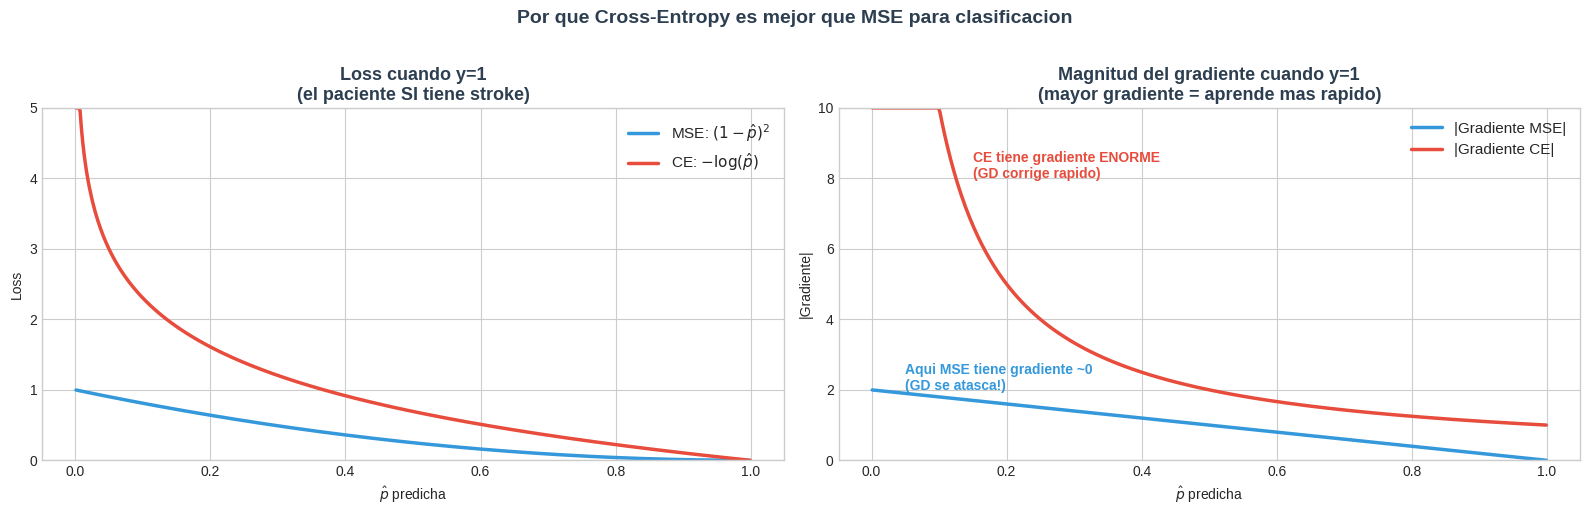

Cuando el modelo predice p=0.05 pero la clase real es 1:
  MSE loss: 0.9025, gradiente: 1.9000
  CE loss:  2.9957, gradiente: 20.0000

CE tiene gradiente 10x mas grande → gradient descent corrige 10x mas rapido.


In [5]:
# === MSE vs Cross-Entropy como loss para clasificacion ===
p_pred = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss cuando y=1
ax = axes[0]
mse_loss = (1 - p_pred)**2
ce_loss = -np.log(p_pred)
ce_loss = np.clip(ce_loss, 0, 5)  # Clip para visualizacion

ax.plot(p_pred, mse_loss, color=C_PRIMARY, linewidth=2.5, label='MSE: $(1-\\hat{p})^2$')
ax.plot(p_pred, ce_loss, color=C_DANGER, linewidth=2.5, label='CE: $-\\log(\\hat{p})$')
ax.set_title('Loss cuando y=1\n(el paciente SI tiene stroke)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel(r'$\hat{p}$ predicha')
ax.set_ylabel('Loss')
ax.legend(fontsize=11)
ax.set_ylim(0, 5)

# Gradientes cuando y=1
ax = axes[1]
mse_grad = -2 * (1 - p_pred)  # d/dp MSE
ce_grad = -1 / p_pred          # d/dp CE
ce_grad = np.clip(ce_grad, -10, 0)

ax.plot(p_pred, np.abs(mse_grad), color=C_PRIMARY, linewidth=2.5, label='|Gradiente MSE|')
ax.plot(p_pred, np.abs(ce_grad), color=C_DANGER, linewidth=2.5, label='|Gradiente CE|')
ax.set_title('Magnitud del gradiente cuando y=1\n(mayor gradiente = aprende mas rapido)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel(r'$\hat{p}$ predicha')
ax.set_ylabel('|Gradiente|')
ax.legend(fontsize=11)
ax.set_ylim(0, 10)

# Anotar zona critica
ax.annotate('Aqui MSE tiene gradiente ~0\n(GD se atasca!)', (0.05, 2), fontsize=10,
            color=C_PRIMARY, fontweight='bold')
ax.annotate('CE tiene gradiente ENORME\n(GD corrige rapido)', (0.15, 8), fontsize=10,
            color=C_DANGER, fontweight='bold')

plt.suptitle('Por que Cross-Entropy es mejor que MSE para clasificacion',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Cuando el modelo predice p=0.05 pero la clase real es 1:")
print(f"  MSE loss: {(1-0.05)**2:.4f}, gradiente: {2*(1-0.05):.4f}")
print(f"  CE loss:  {-np.log(0.05):.4f}, gradiente: {1/0.05:.4f}")
print("\nCE tiene gradiente 10x mas grande → gradient descent corrige 10x mas rapido.")

## 6. Ejemplo Practico: Cross-Entropy en Accion

Veamos como cross-entropy guia a gradient descent en un problema de clasificacion simple.

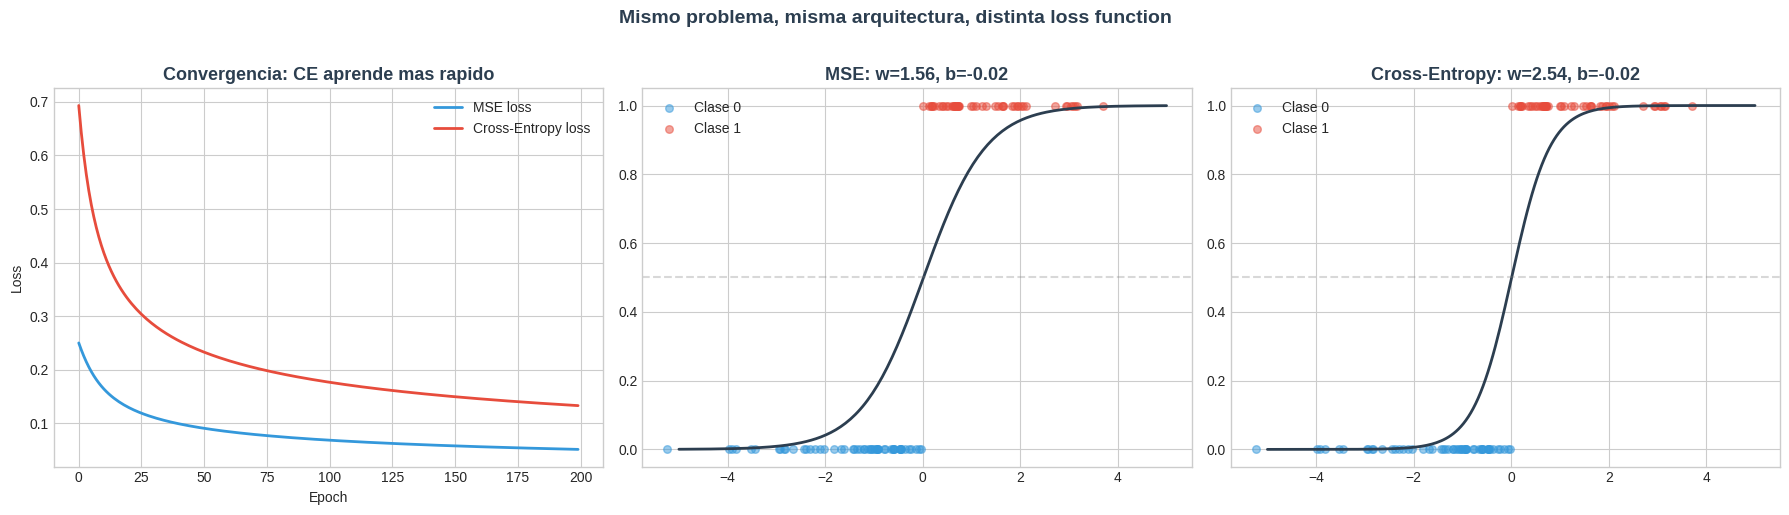

In [6]:
# === Gradient Descent con Cross-Entropy vs MSE ===
np.random.seed(42)

# Datos: 100 puntos, clasificacion binaria
X = np.random.randn(100, 1) * 2
y = (X.ravel() > 0).astype(float)

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Entrenar con MSE
w_mse, b_mse = 0.0, 0.0
losses_mse = []
lr = 0.1

for epoch in range(200):
    z = w_mse * X.ravel() + b_mse
    p = sigmoid(z)
    loss = np.mean((y - p)**2)
    losses_mse.append(loss)
    # Gradientes MSE
    dz = -2 * (y - p) * p * (1 - p)
    w_mse -= lr * np.mean(dz * X.ravel())
    b_mse -= lr * np.mean(dz)

# Entrenar con Cross-Entropy
w_ce, b_ce = 0.0, 0.0
losses_ce = []

for epoch in range(200):
    z = w_ce * X.ravel() + b_ce
    p = sigmoid(z)
    p = np.clip(p, 1e-7, 1-1e-7)
    loss = -np.mean(y * np.log(p) + (1-y) * np.log(1-p))
    losses_ce.append(loss)
    # Gradientes CE
    dz = p - y
    w_ce -= lr * np.mean(dz * X.ravel())
    b_ce -= lr * np.mean(dz)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convergencia
ax = axes[0]
ax.plot(losses_mse, color=C_PRIMARY, linewidth=2, label='MSE loss')
ax.plot(losses_ce, color=C_DANGER, linewidth=2, label='Cross-Entropy loss')
ax.set_title('Convergencia: CE aprende mas rapido', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

# Frontera de decision MSE
ax = axes[1]
x_line = np.linspace(-5, 5, 200)
p_line_mse = sigmoid(w_mse * x_line + b_mse)
ax.scatter(X[y==0], y[y==0], color=C_PRIMARY, alpha=0.5, s=30, label='Clase 0')
ax.scatter(X[y==1], y[y==1], color=C_DANGER, alpha=0.5, s=30, label='Clase 1')
ax.plot(x_line, p_line_mse, color=C_DARK, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.set_title(f'MSE: w={w_mse:.2f}, b={b_mse:.2f}', fontsize=13, fontweight='bold', color=C_DARK)
ax.legend()

# Frontera de decision CE
ax = axes[2]
p_line_ce = sigmoid(w_ce * x_line + b_ce)
ax.scatter(X[y==0], y[y==0], color=C_PRIMARY, alpha=0.5, s=30, label='Clase 0')
ax.scatter(X[y==1], y[y==1], color=C_DANGER, alpha=0.5, s=30, label='Clase 1')
ax.plot(x_line, p_line_ce, color=C_DARK, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.set_title(f'Cross-Entropy: w={w_ce:.2f}, b={b_ce:.2f}', fontsize=13, fontweight='bold', color=C_DARK)
ax.legend()

plt.suptitle('Mismo problema, misma arquitectura, distinta loss function',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 7. Resumen

| Concepto | Formula | Que mide | Uso en ML |
|---|---|---|---|
| **Informacion** | $I(x) = -\log P(x)$ | Sorpresa de un evento | Base teorica |
| **Entropia** | $H(P) = -\sum P \log P$ | Incertidumbre promedio | Medir desorden en datos |
| **Cross-Entropy** | $H(P,Q) = -\sum P \log Q$ | Error de usar Q para representar P | **Loss function en clasificacion** |
| **KL-Divergence** | $D_{KL} = H(P,Q) - H(P)$ | Distancia entre distribuciones | GANs, VAEs, destilacion |

### La cadena logica completa

1. Shannon define informacion como sorpresa: $I(x) = -\log P(x)$
2. Entropia es la sorpresa promedio: $H(P) = E[I(x)]$
3. Cross-entropy mide que tan bien Q aproxima P: $H(P,Q)$
4. Minimizar cross-entropy con gradient descent = hacer que el modelo se acerque a la realidad
5. **Es exactamente lo que hacen sklearn, Keras y PyTorch cuando entrenas un clasificador**

Todo se reduce a: gradient descent buscando la distribucion predicha que mas se parece a la real.

# Teoria de la Informacion para Machine Learning

**Pregunta:** En clasificacion usamos cross-entropy como loss function. Pero que ES la entropia? Por que funciona? Y que tiene que ver con la informacion?

---

## 1. La Idea Central: Informacion = Sorpresa

Claude Shannon (1948) definio la **informacion** de un evento como una medida de lo **sorprendente** que es:

$$I(x) = -\log_2 P(x)$$

- Evento muy probable (P=0.99): poca sorpresa, poca informacion → $-\log_2(0.99) = 0.014$ bits
- Evento raro (P=0.01): mucha sorpresa, mucha informacion → $-\log_2(0.01) = 6.64$ bits

**Analogia:** Si te digo "manana sale el sol" (P≈1), no te aporto informacion. Si te digo "manana hay terremoto" (P≈0.001), eso SI es informacion.

El logaritmo hace que la informacion sea **aditiva**: dos eventos independientes tienen informacion total = suma de informaciones individuales.

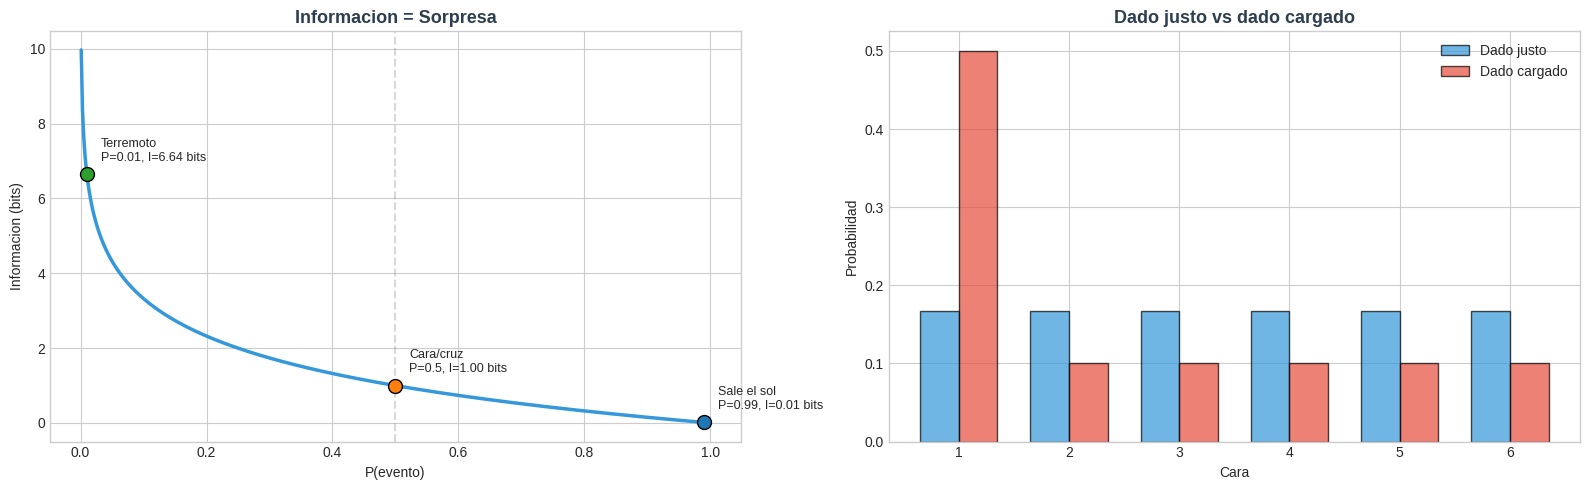

Informacion de sacar un 6 con dado justo: 2.58 bits
Informacion de sacar un 1 con dado cargado: 1.00 bits
Informacion de sacar un 6 con dado cargado: 3.32 bits


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'

# === Informacion vs Probabilidad ===
p = np.linspace(0.001, 0.999, 500)
info = -np.log2(p)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(p, info, color=C_PRIMARY, linewidth=2.5)
ax.set_title('Informacion = Sorpresa', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('P(evento)')
ax.set_ylabel('Informacion (bits)')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3)

# Anotar ejemplos
examples = [(0.99, 'Sale el sol'), (0.5, 'Cara/cruz'), (0.01, 'Terremoto')]
for prob, label in examples:
    info_val = -np.log2(prob)
    ax.scatter([prob], [info_val], s=100, zorder=5, edgecolors='black')
    ax.annotate(f'{label}\nP={prob}, I={info_val:.2f} bits', (prob, info_val),
                textcoords="offset points", xytext=(10, 10), fontsize=9)

# Ejemplo: dado justo vs cargado
ax = axes[1]
dado_justo = np.ones(6) / 6
dado_cargado = np.array([0.5, 0.1, 0.1, 0.1, 0.1, 0.1])

x = np.arange(1, 7)
width = 0.35
ax.bar(x - width/2, dado_justo, width, color=C_PRIMARY, alpha=0.7, label='Dado justo', edgecolor='black')
ax.bar(x + width/2, dado_cargado, width, color=C_DANGER, alpha=0.7, label='Dado cargado', edgecolor='black')
ax.set_title('Dado justo vs dado cargado', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Cara')
ax.set_ylabel('Probabilidad')
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Informacion de sacar un 6 con dado justo: {-np.log2(1/6):.2f} bits")
print(f"Informacion de sacar un 1 con dado cargado: {-np.log2(0.5):.2f} bits")
print(f"Informacion de sacar un 6 con dado cargado: {-np.log2(0.1):.2f} bits")

## 2. Entropia: La Sorpresa Promedio

La **entropia** de una distribucion es la informacion promedio (sorpresa esperada):

$$H(P) = -\sum_{i} P(x_i) \log_2 P(x_i)$$

- **Maxima entropia:** cuando todos los eventos son igualmente probables (dado justo). Maxima incertidumbre.
- **Minima entropia (= 0):** cuando un evento tiene P=1. Certeza total, ninguna sorpresa.

### Interpretacion en ML

La entropia mide que tan **desordenada o incierta** es una distribucion:
- Dataset con 50% gatos, 50% perros → entropia ALTA (dificil de predecir)
- Dataset con 99% gatos, 1% perros → entropia BAJA (casi siempre es gato)

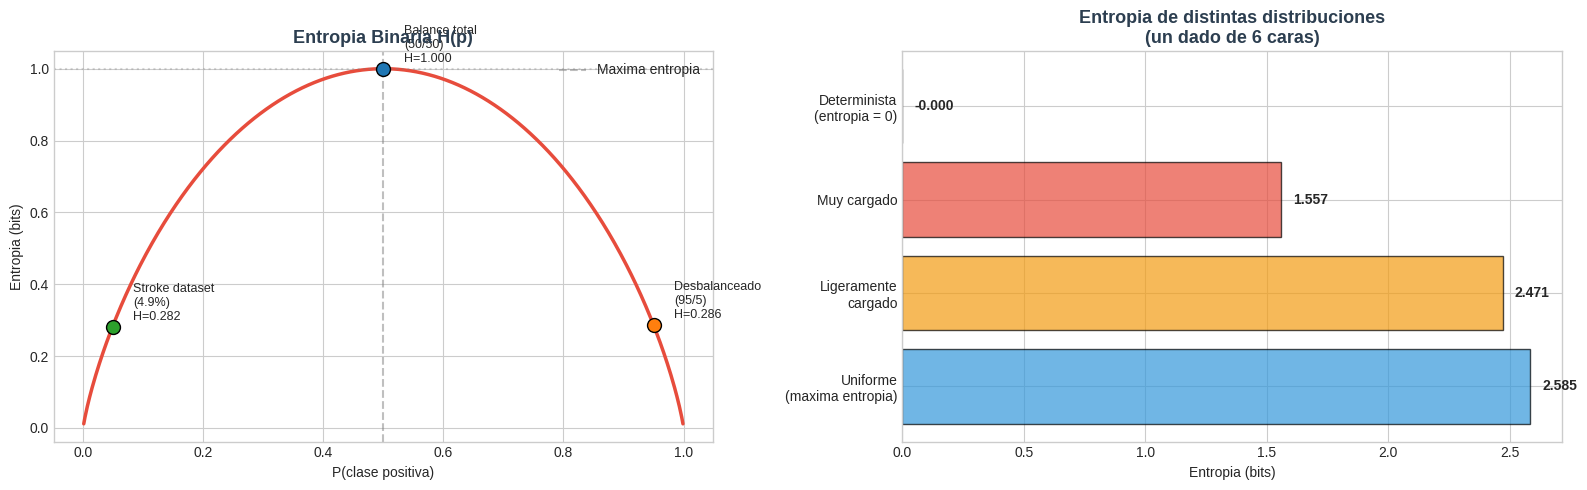

Entropia maxima de 6 opciones = log2(6) = 2.585 bits
Cuanto mas incierta la distribucion, mayor la entropia.


In [8]:
# === Entropia para distribucion binaria ===
def entropy_binary(p):
    """Entropia de una distribucion binaria [p, 1-p]."""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

p_range = np.linspace(0.001, 0.999, 500)
H = [entropy_binary(p) for p in p_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Entropia binaria
ax = axes[0]
ax.plot(p_range, H, color=C_DANGER, linewidth=2.5)
ax.set_title('Entropia Binaria H(p)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('P(clase positiva)')
ax.set_ylabel('Entropia (bits)')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Maxima entropia')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3)

# Anotar casos
cases = [
    (0.5, 'Balance total\n(50/50)'),
    (0.95, 'Desbalanceado\n(95/5)'),
    (0.049, 'Stroke dataset\n(4.9%)'),
]
for prob, label in cases:
    h = entropy_binary(prob)
    ax.scatter([prob], [h], s=100, zorder=5, edgecolors='black')
    ax.annotate(f'{label}\nH={h:.3f}', (prob, h), textcoords="offset points",
                xytext=(15, 5), fontsize=9)
ax.legend()

# Entropia de distribuciones discretas
ax = axes[1]
distributions = {
    'Uniforme\n(maxima entropia)': np.ones(6)/6,
    'Ligeramente\ncargado': np.array([0.3, 0.2, 0.15, 0.15, 0.1, 0.1]),
    'Muy cargado': np.array([0.7, 0.1, 0.05, 0.05, 0.05, 0.05]),
    'Determinista\n(entropia = 0)': np.array([1.0, 0, 0, 0, 0, 0]),
}

names = []
entropies = []
colors = [C_PRIMARY, C_ORANGE, C_DANGER, C_DARK]
for (name, dist), color in zip(distributions.items(), colors):
    h = -np.sum([p * np.log2(p) if p > 0 else 0 for p in dist])
    names.append(name)
    entropies.append(h)

ax.barh(range(len(names)), entropies, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Entropia (bits)')
ax.set_title('Entropia de distintas distribuciones\n(un dado de 6 caras)', fontsize=13, fontweight='bold', color=C_DARK)

for i, h in enumerate(entropies):
    ax.text(h + 0.05, i, f'{h:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Entropia maxima de 6 opciones = log2(6) =", np.log2(6).round(3), "bits")
print("Cuanto mas incierta la distribucion, mayor la entropia.")